# Gerar bacias a montante

Este notebook deriva, para cada reservatório da lista nova, a **bacia de contribuição a montante** usando as Ottobacias.

- `reservatorios_clustering.get_reservatorios_df()` — lê `dados/coordenadasUHEs_clustering.csv`
- `gerar_bacias_ottobacias.processar_reservatorios()` — encontra o trecho de drenagem mais próximo, percorre o grafo a montante e dissolve os polígonos


In [1]:
from pathlib import Path

from reservatorios_clustering import get_reservatorios_df
from gerar_bacias_ottobacias import processar_reservatorios

# Caminhos (relativos à pasta 'merge teste')
OTTOBACIAS_DIR = Path("./dados/ottobacias")
OUTPUT_DIR = Path("./dados/bacias_clustering")
CSV_RES = Path("./dados/coordenadasUHEs_clustering.csv")

## 1. Carregar a lista de reservatórios

O loader normaliza o CSV para o schema esperado pelo pipeline (`nome, rio, uf, lat_dam, lon_dam, buffer_deg`).

In [2]:
df_res = get_reservatorios_df(CSV_RES)
print(f"{len(df_res)} reservatórios")
df_res

32 reservatórios


,nome,rio,uf,lat_dam,lon_dam,buffer_deg
0,14 DE JULHO,,,-29.069444,-51.675278,1.0
1,A. VERMELHA,,,-19.868056,-50.342778,1.0
2,B.COQUEIROS,,,-18.721111,-51.004444,1.0
3,BALBINA,,,-1.913611,-59.473889,1.0
4,BATALHA,,,-17.345556,-47.489444,1.0
5,CANOAS II,,,-22.937778,-50.248889,1.0
6,CAPIVARA,,,-22.661111,-51.353889,1.0
7,CASTRO ALVES,,,-29.004444,-51.384167,1.0
8,COLIDER,,,-10.975556,-55.763333,1.0
9,D. FRANCISCA,,,-29.449444,-53.283333,1.0


## 2. Gerar as bacias

Roda o pipeline completo e salva `bacias_contribuicao.shp`/`.gpkg` em `dados/bacias_clustering/`.

Reservatórios sem trecho/bacia encontrados aparecem na lista de falhas e usarão *fallback* (buffer) na extração de precipitação.

In [3]:
gdf_bacias = processar_reservatorios(
    ottobacias_dir=OTTOBACIAS_DIR,
    output_dir=OUTPUT_DIR,
    df_res=df_res,
    output_name="bacias_contribuicao",
)
gdf_bacias[["nome", "rio", "uf"]]

Carregando trechos de drenagem: geoft_bho_2017_5k_trecho_drenagem.gpkg
  464067 trechos carregados
Carregando áreas de drenagem: geoft_bho_2017_5k_area_drenagem.gpkg
  464067 áreas carregadas
  Reprojetando trechos de EPSG:4674 para EPSG:4326...
  Reprojetando áreas de EPSG:4674 para EPSG:4326...
Construindo grafo de drenagem...
  Grafo construído: 232022 nós com afluentes
Indexando dados...

Processando 32 reservatórios...

14 DE JULHO (, ) - [-29.0694, -51.6753]


c:\Users\PersioPuertasGarciaL\Documents\Codigos\trabalhando\merge teste\gerar_bacias_ottobacias.py:168: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distancias = candidatos.geometry.distance(ponto)
c:\Users\PersioPuertasGarciaL\Documents\Codigos\trabalhando\merge teste\gerar_bacias_ottobacias.py:168: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distancias = candidatos.geometry.distance(ponto)


  Rio BHO: '?' (fallback - '' não encontrado no raio)
  Trecho: 454378 | Cobacia: 786713 | Área acum.: 9.27112645271374 km²
  Percorrendo grafo a montante...
  Trechos a montante: 295
  Bacia gerada: ~14,832 km² (aprox.)

A. VERMELHA (, ) - [-19.8681, -50.3428]
  Rio BHO: '?' (fallback - '' não encontrado no raio)
  Trecho: 377526 | Cobacia: 86815373 | Área acum.: 2.49350941853634 km²
  Percorrendo grafo a montante...
  Trechos a montante: 14831
  Bacia gerada: ~149,898 km² (aprox.)

B.COQUEIROS (, ) - [-18.7211, -51.0044]
  Rio BHO: '?' (fallback - '' não encontrado no raio)
  Trecho: 92376 | Cobacia: 8691813375 | Área acum.: 0.859536599102763 km²
  Percorrendo grafo a montante...
  Trechos a montante: 1335


c:\Users\PersioPuertasGarciaL\Documents\Codigos\trabalhando\merge teste\gerar_bacias_ottobacias.py:168: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distancias = candidatos.geometry.distance(ponto)


  Bacia gerada: ~13,362 km² (aprox.)

BALBINA (, ) - [-1.9136, -59.4739]
  Rio BHO: '?' (fallback - '' não encontrado no raio)
  Trecho: 438643 | Cobacia: 4582539 | Área acum.: 71.4254314946137 km²
  Percorrendo grafo a montante...
  Trechos a montante: 279
  Bacia gerada: ~18,986 km² (aprox.)

BATALHA (, ) - [-17.3456, -47.4894]
  Rio BHO: '?' (fallback - '' não encontrado no raio)
  Trecho: 115000 | Cobacia: 86999511 | Área acum.: 5.00645647276872 km²
  Percorrendo grafo a montante...
  Trechos a montante: 595


...

c:\Users\PersioPuertasGarciaL\Documents\Codigos\trabalhando\merge teste\gerar_bacias_ottobacias.py:168: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distancias = candidatos.geometry.distance(ponto)


  Bacia gerada: ~632,539 km² (aprox.)

BILLINGS (, ) - [-28.5558, -52.5456]
  Rio BHO: '?' (fallback - '' não encontrado no raio)
  Trecho: 330758 | Cobacia: 789995 | Área acum.: 89.2534693441475 km²
  Percorrendo grafo a montante...
  Trechos a montante: 37
  Bacia gerada: ~1,289 km² (aprox.)

PONTE NOVA (, ) - [-23.4544, -46.9098]
  Rio BHO: '?' (fallback - '' não encontrado no raio)
  Trecho: 131822 | Cobacia: 8669733 | Área acum.: 15.9655601792675 km²
  Percorrendo grafo a montante...
  Trechos a montante: 521


c:\Users\PersioPuertasGarciaL\Documents\Codigos\trabalhando\merge teste\gerar_bacias_ottobacias.py:168: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distancias = candidatos.geometry.distance(ponto)
c:\Users\PersioPuertasGarciaL\Documents\Codigos\trabalhando\merge teste\gerar_bacias_ottobacias.py:168: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  distancias = candidatos.geometry.distance(ponto)


  Bacia gerada: ~5,261 km² (aprox.)


Shapefile salvo: dados\bacias_clustering\bacias_contribuicao.shp
  Bacias geradas: 32/32
  GeoPackage salvo: dados\bacias_clustering\bacias_contribuicao.gpkg


,nome,rio,uf
0,14 DE JULHO,,
1,A. VERMELHA,,
2,B.COQUEIROS,,
3,BALBINA,,
4,BATALHA,,
5,CANOAS II,,
6,CAPIVARA,,
7,CASTRO ALVES,,
8,COLIDER,,
9,D. FRANCISCA,,


## 3. Visualizar as bacias geradas

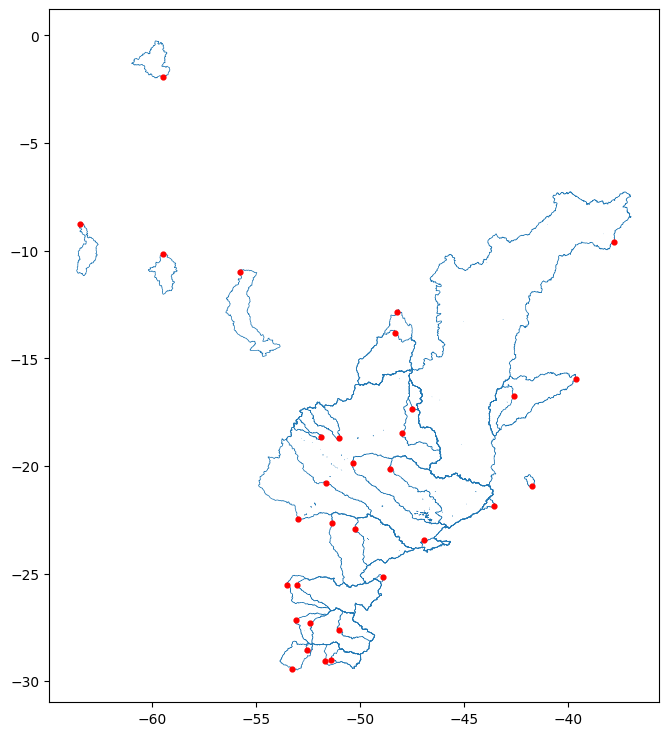

In [4]:
import matplotlib.pyplot as plt

ax = gdf_bacias.boundary.plot(figsize=(9, 9), linewidth=0.5)
ax.scatter(df_res["lon_dam"], df_res["lat_dam"], c="red", s=12, zorder=5)
plt.show()